# 18 · Coupled sizing: aircraft, mission, requirements, reserves and stability in one problem

This is the top of the ladder before the Halo. `examples/coupled_sizing.py` (214 lines) sizes a four-rotor series-hybrid aircraft with
**one explicit Opti, readable top to bottom**: design variables for the airframe and every powertrain rating, a semi-free mission with energy
allocation, the capability requirements, an engine-out battery reserve, stability and failed-rotor control, mass closure, and an objective. Every
piece is something an earlier tutorial built on its own. The Halo driver (tutorials 19-20) has exactly this structure, with higher-fidelity
models and more points.

**In this notebook**
1. The problem statement, as code.
2. Solving it; what the problem looks like (size, sparsity).
3. What sizes the aircraft: the binding list, read component by component.
4. What each constraint costs: multipliers by name, verified with a re-solve.
5. Changing the objective: minimum mass versus minimum fuel.
6. The structure carried into the Halo.

**Run time:** about 15 seconds.

In [1]:
from tutorial_helpers import *
import numpy as onp
import inspect
from dataclasses import replace
from aircraft_closure.requirements.capability import RequirementSet
from examples.coupled_sizing import solve_coupled_sizing

## 1. The problem statement, as code

Read the function once from top to bottom. Its sections are labelled; each maps to a tutorial:

| Section | What | Tutorial |
|---|---|---|
| Design variables | MTOM, fuel load, wing position and area, tail areas, rubber machine torques, turboshaft rating, battery power and energy, disk area | 02, 05-08, 16 |
| Mission variable | cruise speed (the energy split of every segment is created inside the flight points) | 17 |
| Aircraft from the variables | `build_series_hybrid_from_sizing`, `build_reference_aircraft` | 11, 12 |
| Mission and requirements | `build_mission` and one `build_flight_point` per requirement | 15-17 |
| Engine-out reserve | a battery-only hover at MTOM from the SOC floor, 60 s, down to an emergency floor | 07, 15 |
| Mass closure | the structural condition fed by the solved cruise (speed, L/D) | 12, 13 |
| Stability and control | static margin, Cn_beta, rudder at 1.2 V_stall with a failed rotor (level flight there is another equality) | 14 |
| Constraints and objective | closure, trim, fuel load = 1.1 × burnt, every margin ≥ 0; minimize MTOM (or fuel) | 03, 04 |

In [2]:
print(inspect.getsource(solve_coupled_sizing))

def solve_coupled_sizing(objective="mass_takeoff", requirements=RequirementSet(), mission=None,
                         aerodynamics=None, verbose=False, max_iter=3000):
    aerodynamics = aerodynamics or SimpleAerodynamics()
    longitudinal, directional = LongitudinalStability(), DirectionalStability()
    mission = mission or reference_mission(hybridization_hover=None, hybridization_other=None,
                                           velocity_cruise_m_s=None)
    opti = asb.Opti()

    # ---- Design variables -------------------------------------------------------------
    mass_takeoff_kg = opti.variable(init_guess=1300, scale=1000, lower_bound=300)
    mass_fuel_kg = opti.variable(init_guess=30, scale=30, lower_bound=0)
    x_le_wing_m = opti.variable(init_guess=3.0, lower_bound=0.5, upper_bound=5.5)
    area_wing_m2 = opti.variable(init_guess=11, lower_bound=3, upper_bound=30)
    area_horizontal_tail_m2 = opti.variable(init_guess=2.0, lower_bound=0.3)
    area_vertical_tail_

Note how short it is for what it does: every discipline sits behind a function that returns expressions, and the driver only declares what is a
variable, what must hold, and what to minimize. Also note the comment on the battery: *on mass alone a battery never pays for itself here (about
0.9 MJ/kg against 12.9 MJ/kg of shaft energy from fuel); the engine-out reserve is what sizes it.* We will see that in the binding list.

## 2. Solving it, and what the problem looks like

`capture_opti` (from the tutorial helpers) records the Opti that library code solves, without changing it, so we can look inside a solve made by
`solve_coupled_sizing`:

In [3]:
import time
with capture_opti() as xray:
    result = solve_coupled_sizing("mass_takeoff")
opti, solution = xray.opti, xray.solution
print(f"solved in {xray.time_s:.2f} s, {solution.stats()['iter_count']} IPOPT iterations; problem {describe_opti(opti)}")
print(f"MTOM {result.mass_takeoff_kg:.1f} kg, empty {result.mass_empty_kg:.1f} kg, fuel {result.mass_fuel_kg:.2f} kg, battery {result.energy_battery_kWh:.1f} kWh")
print(f"wing {result.area_wing_m2:.2f} m2, tails {result.area_horizontal_tail_m2:.2f} / {result.area_vertical_tail_m2:.2f} m2, disk {result.area_disk_m2:.2f} m2")
print(f"motor {result.power_rated_motor_W / 1e3:.1f} kW x4, generator {result.power_rated_generator_W / 1e3:.1f} kW, turboshaft {result.power_rated_turboshaft_W / 1e3:.1f} kW, "
      f"battery {result.power_max_discharge_battery_W / 1e3:.1f} kW")
print(f"cruise {result.velocity_cruise_m_s:.1f} m/s, L/D {result.lift_to_drag_cruise:.2f}; static margin {result.static_margin:.3f}, Cn_beta {result.cn_beta_per_rad:.3f}")
check("mass closes", abs(result.closure_residual_kg) < 1e-6)

solved in 0.32 s, 28 IPOPT iterations; problem {'variables': 61, 'constraints': 297, 'equalities': 33, 'inequalities': 264}
MTOM 883.6 kg, empty 561.0 kg, fuel 22.65 kg, battery 13.5 kWh
wing 5.05 m2, tails 1.24 / 1.09 m2, disk 4.62 m2
motor 46.8 kW x4, generator 175.3 kW, turboshaft 175.3 kW, battery 160.9 kW
cruise 45.3 m/s, L/D 8.13; static margin 0.100, Cn_beta 0.060
PASS  mass closes


The constraint Jacobian of an all-at-once problem is **sparse and block-structured**: each flight point's equations involve its own state variables
plus the shared design variables. That structure is what makes the formulation cheap for IPOPT (sparse linear algebra) and it is visible directly:

Jacobian 297 x 61, 1067 nonzeros (5.9% dense)


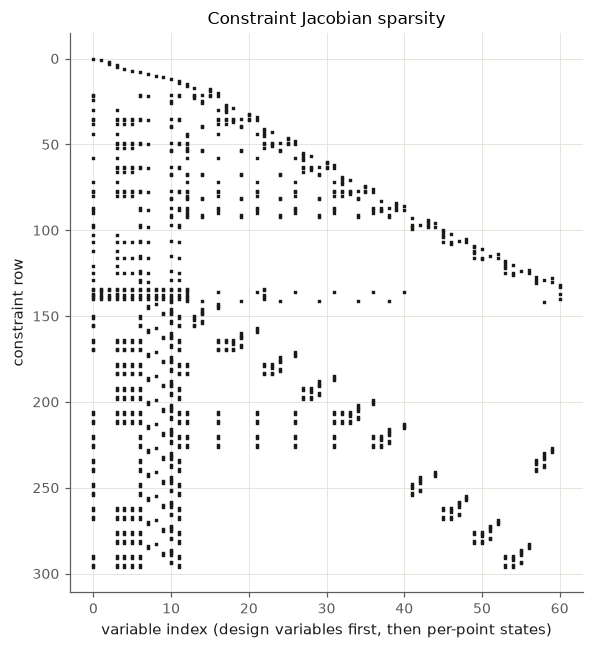

In [4]:
import casadi as cas
jacobian_sparsity = cas.jacobian(opti.g, opti.x).sparsity()
rows, cols = jacobian_sparsity.get_triplet()
print(f"Jacobian {jacobian_sparsity.size1()} x {jacobian_sparsity.size2()}, {jacobian_sparsity.nnz()} nonzeros "
      f"({jacobian_sparsity.nnz() / (jacobian_sparsity.size1() * jacobian_sparsity.size2()):.1%} dense)")
fig, ax = plt.subplots(figsize=(5.5, 6))
ax.plot(cols, rows, "s", color=ink, markersize=1.2, linestyle="none")
ax.invert_yaxis(); ax.set(xlabel="variable index (design variables first, then per-point states)", ylabel="constraint row",
                          title="Constraint Jacobian sparsity")
plt.tight_layout(); plt.show()

The first columns (design variables: MTOM, ratings, areas) are dense: every point depends on them. Each later block of columns is one flight point's
own states (rotor speed, current, torque, alpha, split), touched only by that point's rows. In MDO terms this is the **block-angular structure of
SAND**: local states, global design variables. Two other features are visible. The diagonal band at the top left is the bound rows (AeroSandbox
writes `lower_bound`/`upper_bound` as constraints, tutorial 02). The rows that reach across many point blocks are the mission chain: a later
segment's mass and SOC depend on the fuel and current of every earlier segment (tutorial 17).

## 3. What sizes the aircraft

In [5]:
for label in result.binding:
    print("  ", label)

   max_speed: turboshaft power_shaft_W
   max_speed: generator power_shaft_W
   engine-out hover: battery discharge_power_W
   hover: motor power_shaft_W
   hover: gearbox power_input_W
   hover: propulsor power_shaft_W
   soc_after_engine_out_hover
   static_margin
   cn_beta_per_rad
   soc_end


Reading it:

| Binding | Sizes |
|---|---|
| `max_speed: turboshaft power_shaft_W`, `max_speed: generator power_shaft_W` | the turbogenerator (sustained speed on turbine power) |
| `hover: motor / gearbox / propulsor ...` | the electric drive (thrust-heavy, battery-assisted) |
| `engine-out hover: battery discharge_power_W`, `soc_after_engine_out_hover` | the battery: power **and** energy, both by the reserve, not by the mission |
| `static_margin`, `cn_beta_per_rad` | the horizontal and vertical tails |
| `soc_end` | the mission spends the battery down to the reserve floor |

This is the same kind of list the Halo produces (tutorial 00), and the same reading: each component is sized by a named requirement.

## 4. What each constraint costs

`all_margins` was a local variable of the solve; `capture_opti` kept it, and the duals returned by the `subject_to` call that constrained them all.
Pair them up and sort by multiplier (tonnes of MTOM per unit of normalized margin):

In [6]:
all_margins = xray.locals["all_margins"]
duals = next(d for c, d in xray.calls if isinstance(d, list) and len(d) == len(all_margins))
priced = sorted(((float(solution.value(d)) if d is not None else 0.0, m.label) for m, d in zip(all_margins, duals)), reverse=True)
print(f"{'multiplier':>11}  margin")
for value, label in priced[:10]:
    print(f"{value:11.4f}  {label}")

 multiplier  margin
     0.1635  max_speed: turboshaft power_shaft_W
     0.0803  max_speed: generator power_shaft_W
     0.0429  engine-out hover: battery discharge_power_W
     0.0345  hover: motor power_shaft_W
     0.0345  hover: gearbox power_input_W
     0.0345  hover: propulsor power_shaft_W
     0.0254  soc_after_engine_out_hover
     0.0033  static_margin
     0.0029  cn_beta_per_rad
     0.0021  soc_end


Verify one sensitivity the robust way, by re-solving. The closure's own sensitivity to payload is the growth factor, and the multiplier of the
closure equality predicts it. Re-solve with 1 kg more payload:

In [7]:
heavier = solve_coupled_sizing("mass_takeoff", requirements=RequirementSet(mass_payload_kg=301.0))
growth = heavier.mass_takeoff_kg - result.mass_takeoff_kg
print(f"growth factor dMTOM/dpayload = {growth:.3f} kg/kg")
check("the coupled growth factor exceeds the structure-only one of tutorial 12 (1.11): power and energy resize too", growth > 1.2)

CasADi - 2026-10-09 02:40:34 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 134, col 0).") [.../casadi/core/oracle_function.cpp:408]


growth factor dMTOM/dpayload = 1.671 kg/kg
PASS  the coupled growth factor exceeds the structure-only one of tutorial 12 (1.11): power and energy resize too


## 5. Changing the objective

The same problem with `objective="fuel"` (minimum mission fuel instead of minimum MTOM):

In [8]:
fuel_optimal = solve_coupled_sizing("fuel")
print(f"{'':<26}{'min MTOM':>12}{'min fuel':>12}")
for label, attribute, scale_ in (("MTOM [kg]", "mass_takeoff_kg", 1), ("fuel [kg]", "mass_fuel_kg", 1), ("battery [kWh]", "energy_battery_kWh", 1),
                                 ("wing [m2]", "area_wing_m2", 1), ("disk [m2]", "area_disk_m2", 1), ("cruise [m/s]", "velocity_cruise_m_s", 1),
                                 ("turboshaft [kW]", "power_rated_turboshaft_W", 1e-3)):
    print(f"{label:<26}{getattr(result, attribute) * scale_:12.2f}{getattr(fuel_optimal, attribute) * scale_:12.2f}")
check("the minimum-fuel design burns no more fuel", fuel_optimal.mass_fuel_kg <= result.mass_fuel_kg + 1e-6)
check("the minimum-MTOM design is no heavier", result.mass_takeoff_kg <= fuel_optimal.mass_takeoff_kg + 1e-6)

                              min MTOM    min fuel
MTOM [kg]                       883.62     2122.62
fuel [kg]                        22.65        1.28
battery [kWh]                    13.54      183.73
wing [m2]                         5.05       20.50
disk [m2]                         4.62       10.82
cruise [m/s]                     45.31       59.99
turboshaft [kW]                 175.35      251.85
PASS  the minimum-fuel design burns no more fuel
PASS  the minimum-MTOM design is no heavier


The contrast is stark. Minimum fuel turns the aircraft into an almost all-electric one: a 184 kWh battery flies nearly the whole mission, fuel
drops to about a kilogram, and take-off mass more than doubles, with a much bigger wing and rotors to carry it. Nothing in the formulation changed
except one line. That is the value of a single coupled problem: the objective's consequences propagate through every discipline consistently.
(It also shows why the objective must reflect what you value: minimum fuel alone is rarely what anyone wants.) The Halo driver offers three
objectives: `"mass_takeoff"`, `"payload"` (maximize payload around the fixed engines) and `"cost"` (cost per mission, `mission/cost.py`).

## 6. The structure carried into the Halo

| Coupled sizing (here) | Halo driver |
|---|---|
| `SeriesHybridSizing` | `HaloDesign` (every sized quantity; numbers or variables) |
| illustrative `RequirementSet` | `HaloRequirements` (payload 900 kg, 445 nm, 210 kt, 13,000 ft, hot-day hover, failure hovers, stall) |
| defaults in the classes | `HaloAssumptions` (~150 documented fields and model switches) |
| `build_reference_aircraft` | `build_halo_aircraft(design, requirements, assumptions)` |
| simple aero, actuator disk, constant battery, Raymer | AeroBuildup, JVX rotor, equivalent-circuit pack, AFDD + calibration, thermal, redundancy, units |
| one solve from a fixed guess | `solve_halo_sizing`: integer machine units, starting-point strategy, precursor problems |
| a result dataclass | `HaloSizingResult` with traces (battery, thermal, failure cases, whirl flutter, cost) |

## Summary

- The coupled problem is a short, readable list of variables, constraints and an objective; every discipline hides behind expression-returning
  functions.
- Its Jacobian is sparse and block-structured: dense in the design variables, block-diagonal in each point's states.
- The binding list says what sizes each component; captured duals price every constraint; re-solves verify.
- The objective is a one-line change; the structure scales directly to the Halo.

## Check yourself

<details><summary>1. Why does the engine-out reserve, not the mission, size the battery here?</summary>

Battery energy is about 14 times less mass-efficient than fuel through the turboshaft, so the optimizer uses as little battery as it can. The mission alone would barely use one. The reserve (60 s of battery-only hover at MTOM from the SOC floor) is a hard requirement that needs both power and energy, so it sets the pack.
</details>

<details><summary>2. Where does the "1.2 V_stall with a failed rotor" point get its angle of attack?</summary>

From its own variable (`alpha_minimum_control_deg`) and the equality `slow.lift_N / weight_N == 1`: a level-flight point at the minimum-control speed, which is itself an expression of MTOM and wing area.
</details>

In [9]:
check_summary()

4 of 4 checks passed
